Loaded: 186 microexon-protein pairs
Microexon pool: 1432 residues (from 186 exons)
Rest-of-protein pool: 252767 residues


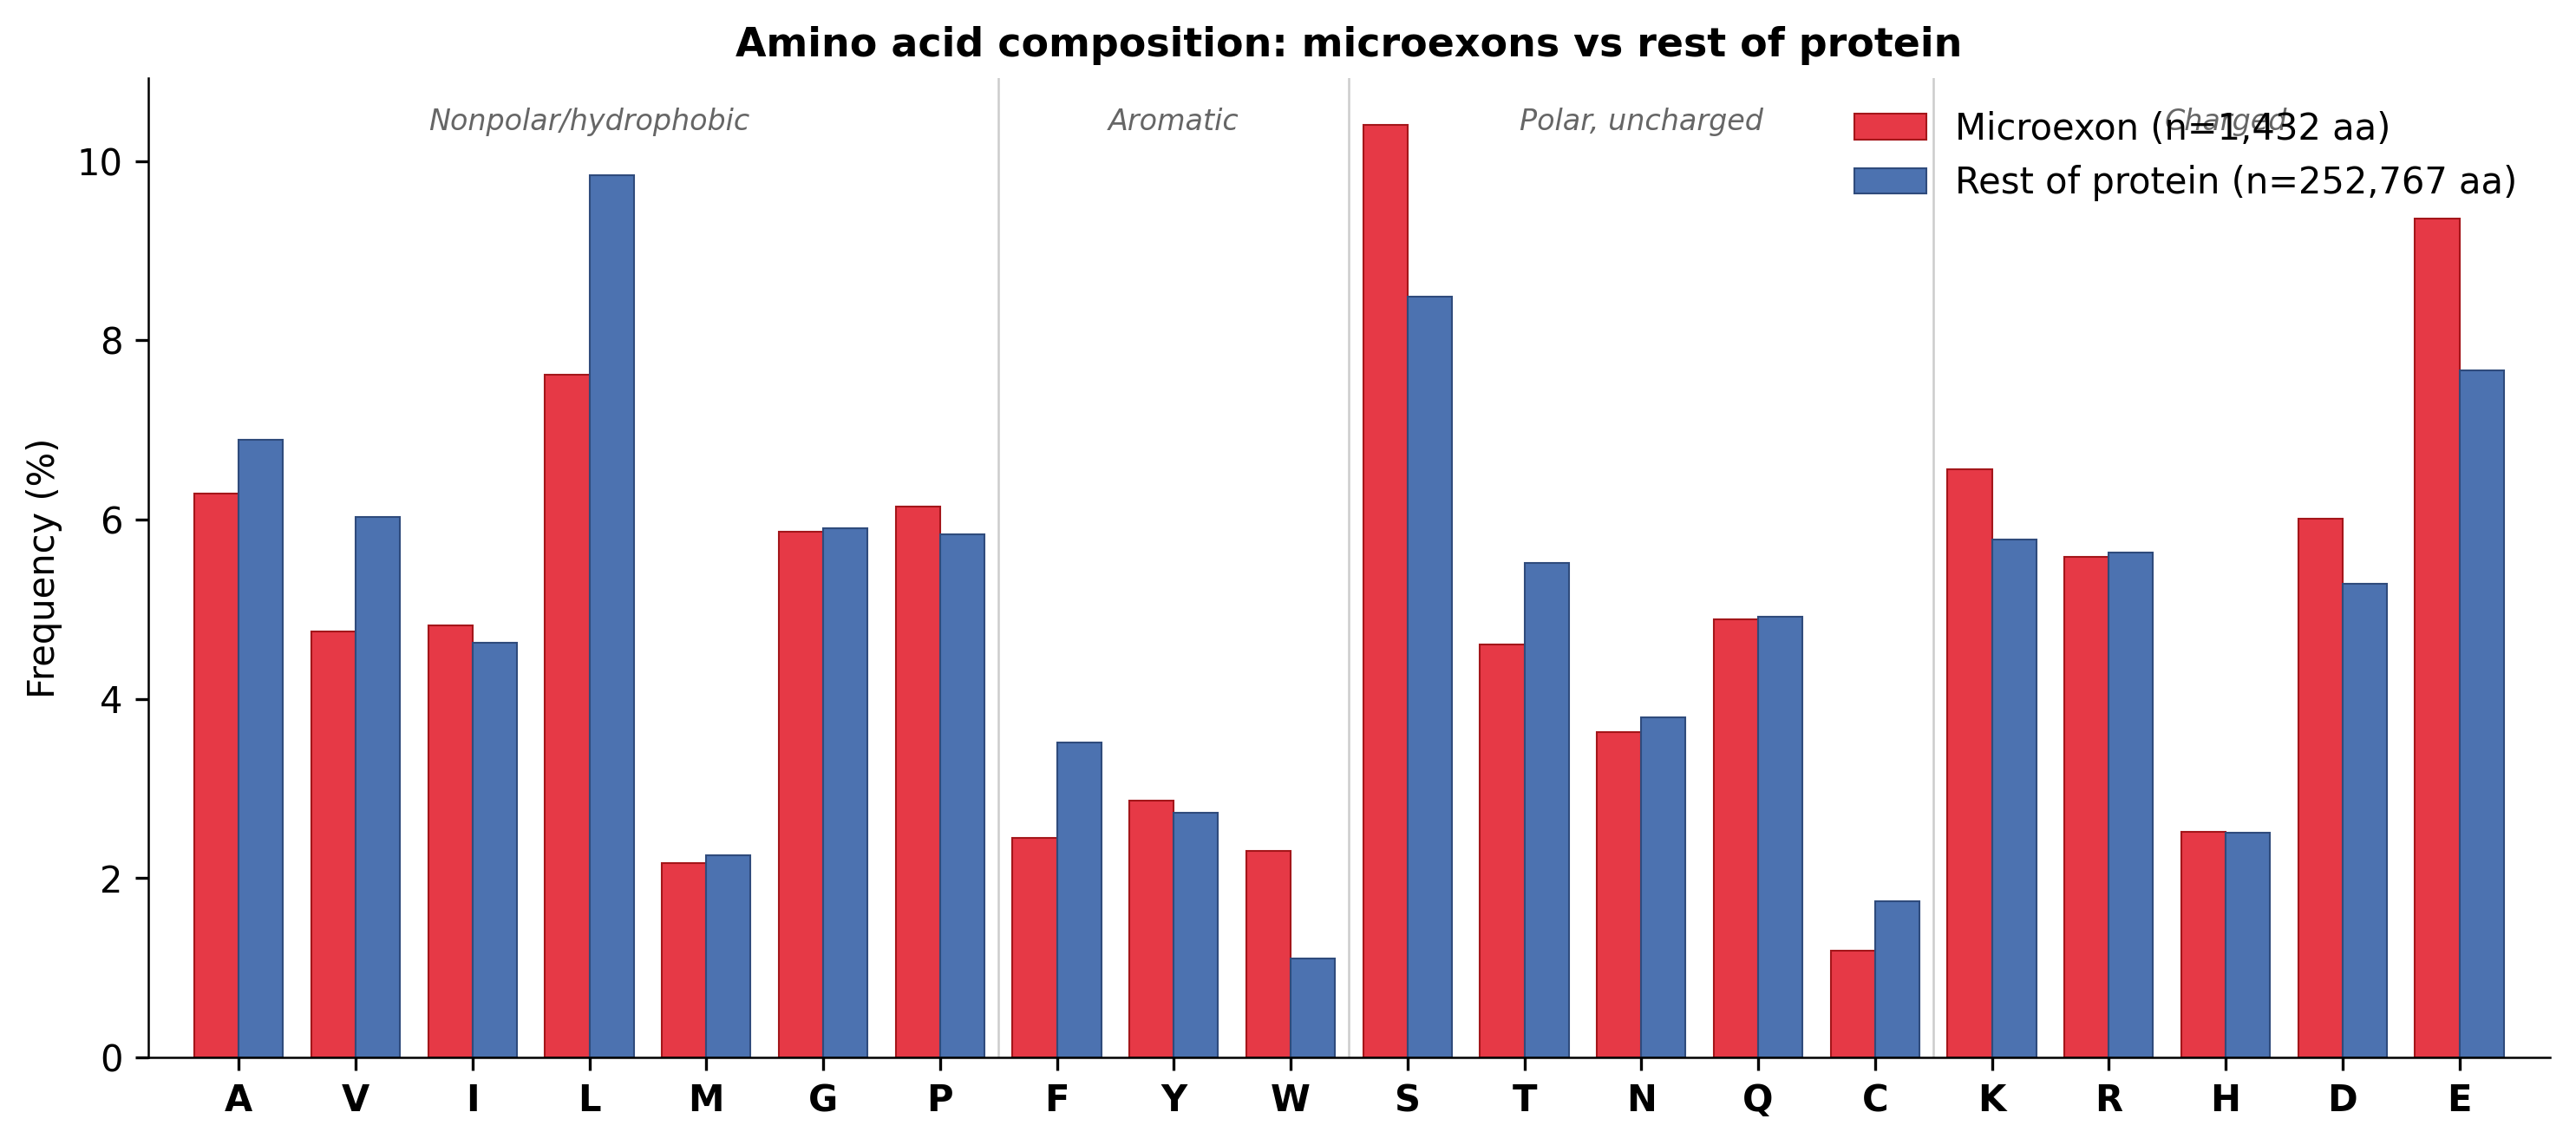

Saved: microexon_aa_composition.png/.svg
Overall chi-squared: chi2=54.80, p=2.50e-05


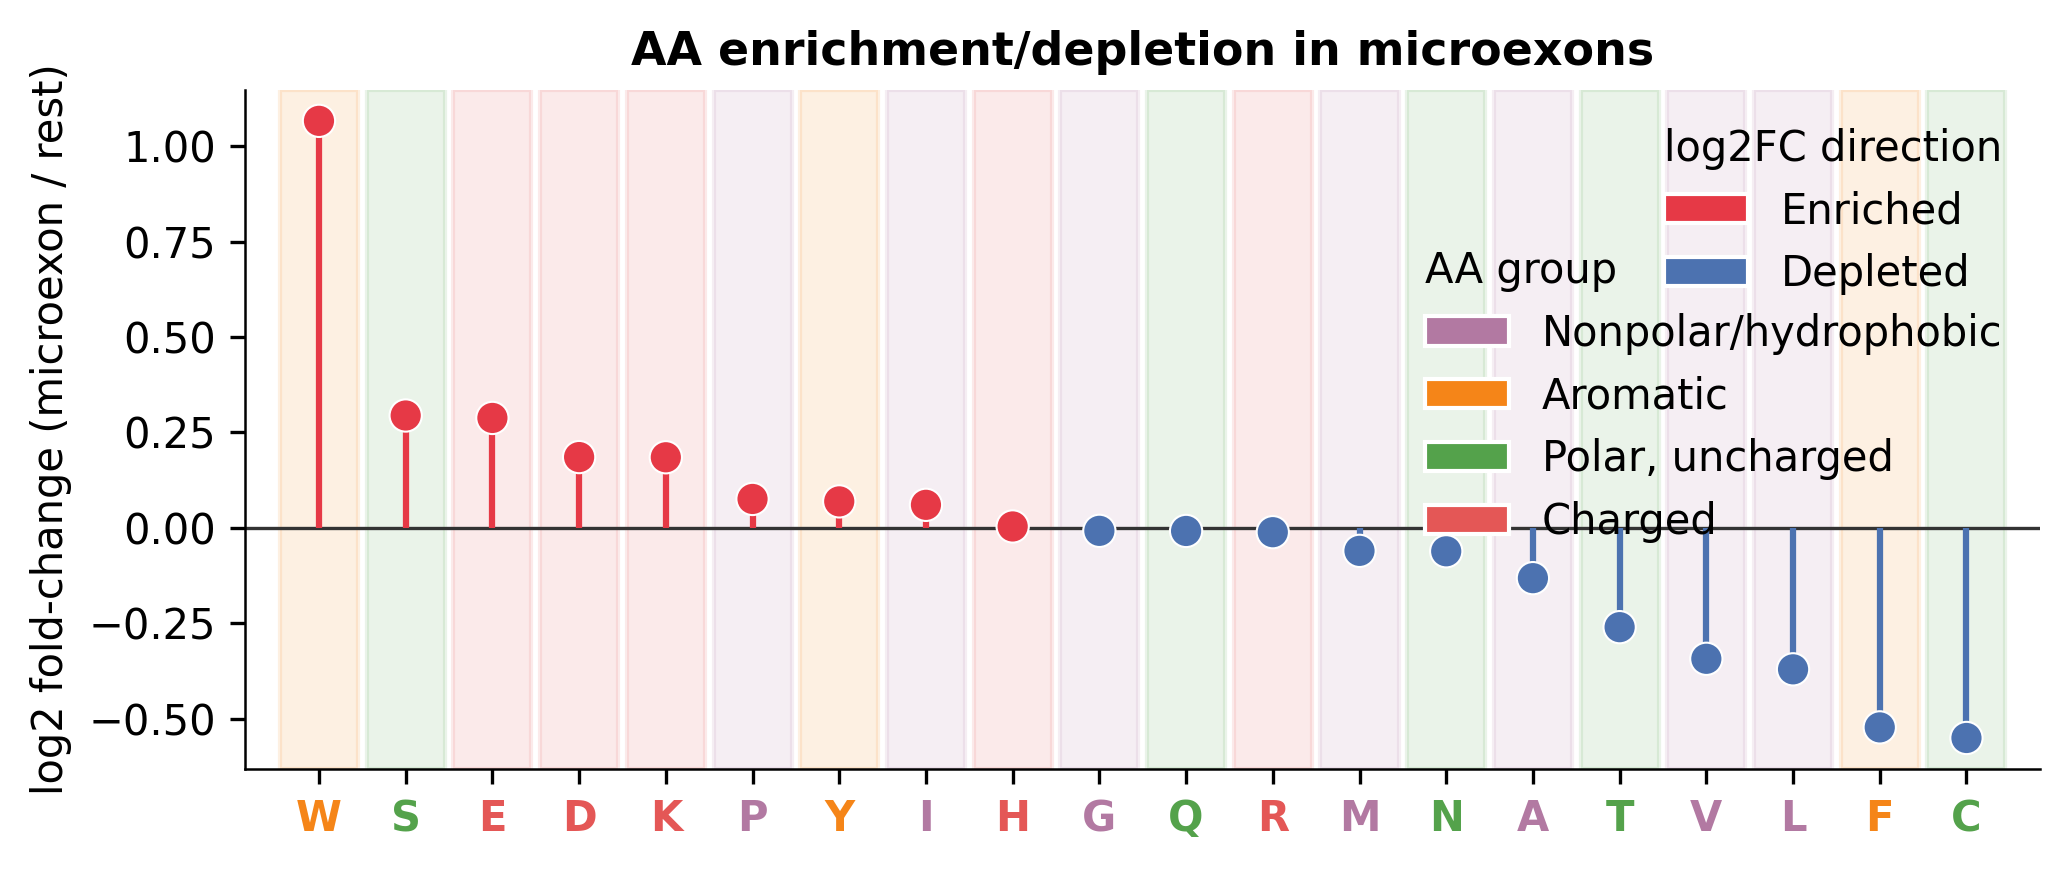

Saved: microexon_aa_log2fc.png/.svg


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact, wilcoxon
from statsmodels.stats.multitest import multipletests

# ---- Config ----
CSV_PATH  = "../outputs/microexon_final.csv"   # <-- change to your path
FONT_SIZE = 10

# Colors (consistent with prior figures)
C_MICRO = "#E63946"; C_REST = "#4C72B0"
C_MICRO_EDGE = "#A4161A"; C_REST_EDGE = "#2F4B7C"
C_ENRICH = "#E63946"; C_DEPLETE = "#4C72B0"

# Standard 20 amino acids
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")

# Physicochemical grouping (4 groups)
AA_ORDER = [
    "A", "V", "I", "L", "M", "G", "P",
    "F", "Y", "W",
    "S", "T", "N", "Q", "C",
    "K", "R", "H", "D", "E",
]

AA_CLASS = {
    "A": "Nonpolar/hydrophobic", "V": "Nonpolar/hydrophobic", "I": "Nonpolar/hydrophobic",
    "L": "Nonpolar/hydrophobic", "M": "Nonpolar/hydrophobic",
    "G": "Nonpolar/hydrophobic", "P": "Nonpolar/hydrophobic",
    "F": "Aromatic", "Y": "Aromatic", "W": "Aromatic",
    "S": "Polar, uncharged", "T": "Polar, uncharged", "N": "Polar, uncharged",
    "Q": "Polar, uncharged", "C": "Polar, uncharged",
    "K": "Charged", "R": "Charged", "H": "Charged",
    "D": "Charged", "E": "Charged",
}

CLASS_COLORS = {
    "Nonpolar/hydrophobic": "#B279A2",  # purple (was blue #4C78A8 — clashed with Depleted)
    "Aromatic": "#F58518",
    "Polar, uncharged": "#54A24B",
    "Charged": "#E45756",
}

# Derive AA_GROUPS (ordered dict) from AA_ORDER + AA_CLASS
AA_GROUPS = {}
for aa in AA_ORDER:
    cls = AA_CLASS[aa]
    AA_GROUPS.setdefault(cls, []).append(aa)

# ---- Fonts: Arial ----
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE, "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE, "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "figure.dpi": 300, "savefig.dpi": 300,
    "pdf.fonttype": 42, "ps.fonttype": 42, "axes.linewidth": 0.6,
    "svg.fonttype": "none",
})

# ---- 1. Load and prepare data ----
df = pd.read_csv(CSV_PATH)
print(f"Loaded: {len(df)} microexon-protein pairs")

micro_pool, rest_pool = [], []
for _, row in df.iterrows():
    exon_seq = str(row["exon_aa_seq"])
    marked = str(row["aa_seq_marked"])
    parts = marked.split("#")
    if len(parts) >= 3:
        rest_seq = parts[0] + parts[2]
    else:
        full = str(row["aa_seq"])
        es, ee = int(row["exon_start"]), int(row["exon_end"])
        rest_seq = full[:es] + full[ee:]
    # Exclude * (stop codon) and non-standard chars
    exon_clean = "".join(c for c in exon_seq if c in AA_LIST)
    rest_clean = "".join(c for c in rest_seq if c in AA_LIST)
    micro_pool.append(exon_clean)
    rest_pool.append(rest_clean)

micro_all = "".join(micro_pool)
rest_all = "".join(rest_pool)
print(f"Microexon pool: {len(micro_all)} residues (from {len(df)} exons)")
print(f"Rest-of-protein pool: {len(rest_all)} residues")

def count_aas(seq):
    return {aa: seq.count(aa) for aa in AA_LIST}

micro_counts = count_aas(micro_all)
rest_counts = count_aas(rest_all)
micro_total = sum(micro_counts.values())
rest_total = sum(rest_counts.values())

# ---- 2. Figure 1: AA composition bar chart ----
micro_freq = np.array([micro_counts[aa] / micro_total * 100 for aa in AA_ORDER])
rest_freq = np.array([rest_counts[aa] / rest_total * 100 for aa in AA_ORDER])

fig1, ax = plt.subplots(figsize=(10, 4.5), facecolor="white")
x = np.arange(len(AA_ORDER)); w = 0.38
ax.bar(x - w/2, micro_freq, w, color=C_MICRO, edgecolor=C_MICRO_EDGE,
       linewidth=0.5, label=f"Microexon (n={micro_total:,} aa)", zorder=2)
ax.bar(x + w/2, rest_freq, w, color=C_REST, edgecolor=C_REST_EDGE,
       linewidth=0.5, label=f"Rest of protein (n={rest_total:,} aa)", zorder=2)
ax.set_xticks(x); ax.set_xticklabels(AA_ORDER, fontweight="bold")
ax.set_ylabel("Frequency (%)")
ax.set_title("Amino acid composition: microexons vs rest of protein",
             fontweight="bold", fontsize=FONT_SIZE + 1)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper right")
ax.margins(x=0.02)
# Group separator lines and labels
pos = 0
for gname, aas in AA_GROUPS.items():
    n = len(aas)
    if pos > 0:
        ax.axvline(pos - 0.5, color="#CCCCCC", linewidth=0.6, zorder=0)
    ax.text(pos + (n-1)/2, ax.get_ylim()[1] * 0.97, gname,
            ha="center", va="top", fontsize=FONT_SIZE - 2, color="#666666", fontstyle="italic")
    pos += n
fig1.tight_layout()
fig1.savefig("../outputs/microexon_aa_composition.png", bbox_inches="tight", facecolor="white")
fig1.savefig("../outputs/microexon_aa_composition.svg", bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: microexon_aa_composition.png/.svg")

# ---- 3. Figure 2: Log2 fold-change lollipop plot ----
results = []
for aa in AA_LIST:
    mc, rc = micro_counts[aa], rest_counts[aa]
    table = [[mc, micro_total - mc], [rc, rest_total - rc]]
    _, p = fisher_exact(table, alternative="two-sided")
    log2fc = np.log2((mc / micro_total + 1e-9) / (rc / rest_total + 1e-9))
    results.append({"AA": aa, "micro_count": mc, "rest_count": rc,
                    "micro_freq": mc/micro_total, "rest_freq": rc/rest_total,
                    "log2FC": log2fc, "fisher_p": p})
aa_stats = pd.DataFrame(results)
_, padj, _, _ = multipletests(aa_stats["fisher_p"].values, method="fdr_bh")
aa_stats["fisher_padj"] = padj
aa_stats["significant"] = aa_stats["fisher_padj"] < 0.05

# Overall chi-squared
contingency = np.array([[micro_counts[aa] for aa in AA_LIST],
                        [rest_counts[aa] for aa in AA_LIST]])
chi2, chi2_p, _, _ = chi2_contingency(contingency)
print(f"Overall chi-squared: chi2={chi2:.2f}, p={chi2_p:.2e}")

# Sort by log2FC descending (most enriched -> most depleted)
aa_stats["class"] = aa_stats["AA"].map(AA_CLASS)
res_sorted = aa_stats.sort_values("log2FC", ascending=False).reset_index(drop=True)

fig2, ax = plt.subplots(figsize=(7, 3), facecolor="white")
x = np.arange(len(res_sorted))
# Background column shade: each column shaded by its AA class color (low alpha)
for xi, aa in zip(x, res_sorted["AA"]):
    ax.axvspan(xi - 0.45, xi + 0.45, color=CLASS_COLORS[AA_CLASS[aa]], alpha=0.12, zorder=0)
# Lollipop colors by sign: positive (enriched) = red, negative (depleted) = blue
sign_colors = [C_ENRICH if v > 0 else C_DEPLETE for v in res_sorted["log2FC"]]
ax.vlines(x, 0, res_sorted["log2FC"], colors=sign_colors, linewidth=1.5, zorder=2)
ax.scatter(x, res_sorted["log2FC"], c=sign_colors, s=60, zorder=3, edgecolors="white", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(res_sorted["AA"], fontweight="bold")
# Color x-axis AA labels by their class color
for tick, aa in zip(ax.get_xticklabels(), res_sorted["AA"]):
    tick.set_color(CLASS_COLORS[AA_CLASS[aa]])
ax.axhline(0, color="#333333", linewidth=0.8, zorder=1)
ax.set_ylabel("log2 fold-change (microexon / rest)")
ax.set_title("AA enrichment/depletion in microexons", fontweight="bold", fontsize=FONT_SIZE + 1)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.margins(x=0.02)
# Legend: two grouped legends — direction (enriched/depleted) and AA class
from matplotlib.patches import Patch
sign_handles = [Patch(facecolor=C_ENRICH, edgecolor="white", label="Enriched"),
                Patch(facecolor=C_DEPLETE, edgecolor="white", label="Depleted")]
class_handles = [Patch(facecolor=c, edgecolor="white", label=g) for g, c in CLASS_COLORS.items()]
leg1 = ax.legend(handles=sign_handles, frameon=False, loc="upper right",
                 fontsize=FONT_SIZE, title="log2FC direction",
                 title_fontsize=FONT_SIZE, alignment="left")
leg1._legend_box.align = "left"
ax.add_artist(leg1)
leg2 = ax.legend(handles=class_handles, frameon=False, loc="upper right",
                 fontsize=FONT_SIZE, title="AA group",
                 title_fontsize=FONT_SIZE, alignment="left",
                 bbox_to_anchor=(1.0, 0.82))
leg2._legend_box.align = "left"
fig2.tight_layout()
fig2.savefig("../outputs/microexon_aa_log2fc.png", bbox_inches="tight", facecolor="white")
fig2.savefig("../outputs/microexon_aa_log2fc.svg", bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: microexon_aa_log2fc.png/.svg")
aa_stats.to_csv("../outputs/microexon_aa_composition_table.csv", index=False)